Let's build this as a clean standalone preprocessing step. We’ll calculate the six descriptors from each GT mask and save one CSV per dataset, plus an optional combined CSV.

MORPHOLOGY SANITY CHECK
Total masks in CSV: 927
Visualizing: 20 masks


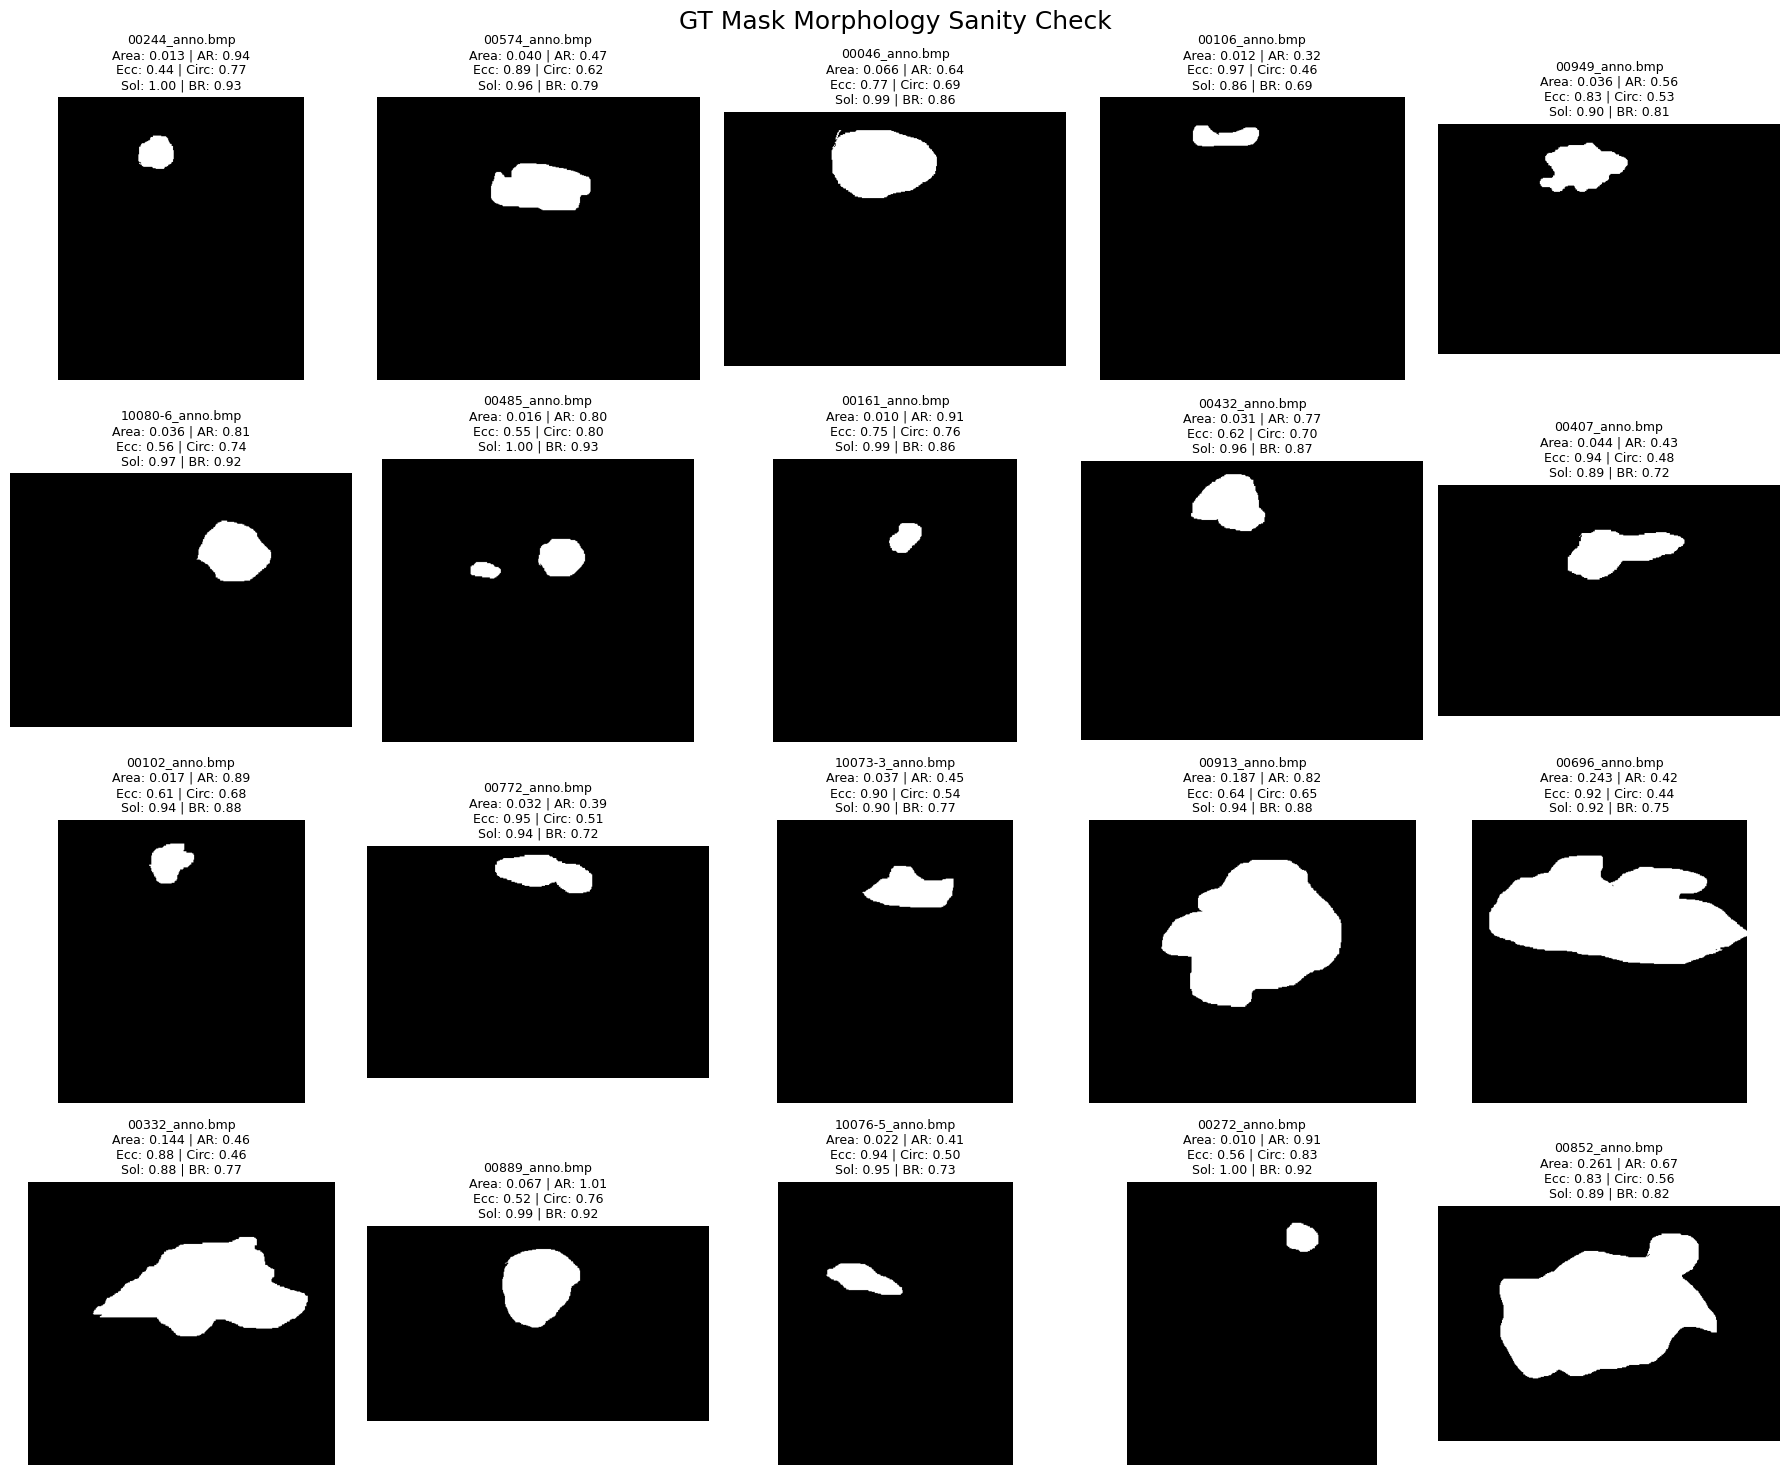

In [12]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# CONFIGURATION
# ============================================================

GT_FOLDER = r"E:\Research Datasets\Datasets\BUSI\masks"

CSV_PATH = r"E:\Research Datasets\Datasets\BUSI\gt_morphology.csv"

# Number of examples to visualize
N_SAMPLES = 20

# ============================================================
# LOAD MORPHOLOGY DATASET
# ============================================================

df = pd.read_csv(CSV_PATH)

print("=" * 60)
print("MORPHOLOGY SANITY CHECK")
print("=" * 60)

print(f"Total masks in CSV: {len(df)}")

# ============================================================
# SELECT RANDOM SAMPLES
# ============================================================

np.random.seed(42)

sample_df = df.sample(
    n=min(N_SAMPLES, len(df)),
    random_state=42
).reset_index(drop=True)

print(f"Visualizing: {len(sample_df)} masks")

# ============================================================
# VISUALIZE
# ============================================================

fig, axes = plt.subplots(
    4, 5,
    figsize=(18, 15)
)

axes = axes.flatten()

for i, row in sample_df.iterrows():

    filename = row["image_name"]

    mask_path = os.path.join(GT_FOLDER, filename)

    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:
        axes[i].axis("off")
        continue

    # Binary mask
    mask = (mask > 0).astype(np.uint8)

    # Display
    axes[i].imshow(mask, cmap="gray")

    axes[i].set_title(
        f"{filename}\n"
        f"Area: {row['normalized_area']:.3f} | "
        f"AR: {row['aspect_ratio']:.2f}\n"
        f"Ecc: {row['eccentricity']:.2f} | "
        f"Circ: {row['circularity']:.2f}\n"
        f"Sol: {row['solidity']:.2f} | "
        f"BR: {row['boundary_regularity']:.2f}",
        fontsize=9
    )

    axes[i].axis("off")

# Turn off unused plots
for j in range(len(sample_df), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "GT Mask Morphology Sanity Check",
    fontsize=18
)

plt.tight_layout()

plt.show()

In [13]:
import os
import cv2
import pandas as pd

GT_FOLDER = r"E:\Research Datasets\Datasets\BUSI\masks"

files = sorted([
    f for f in os.listdir(GT_FOLDER)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"))
])

multi_component = []
single_component = 0

for filename in files:

    path = os.path.join(GT_FOLDER, filename)

    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if mask is None:
        continue

    mask = (mask > 0).astype("uint8")

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    # subtract background
    lesion_components = num_labels - 1

    if lesion_components > 1:

        multi_component.append({
            "image_name": filename,
            "components": lesion_components
        })

    else:
        single_component += 1


# ============================================================
# RESULTS
# ============================================================

multi_df = pd.DataFrame(multi_component)

print("=" * 60)
print("CONNECTED COMPONENT AUDIT")
print("=" * 60)

print(f"Total masks: {len(files)}")
print(f"Single-component masks: {single_component}")
print(f"Multi-component masks: {len(multi_df)}")

print()

if len(multi_df) > 0:

    print("Multi-component masks:")
    print(multi_df.to_string(index=False))

else:

    print("No multi-component masks found.")

CONNECTED COMPONENT AUDIT
Total masks: 927
Single-component masks: 880
Multi-component masks: 47

Multi-component masks:
      image_name  components
  00068_anno.bmp           2
  00130_anno.bmp           2
  00151_anno.bmp           2
  00181_anno.bmp           3
  00198_anno.bmp           3
  00207_anno.bmp           2
  00209_anno.bmp           2
  00264_anno.bmp           2
  00267_anno.bmp           2
  00326_anno.bmp           2
  00335_anno.bmp           2
  00356_anno.bmp           3
  00395_anno.bmp           2
  00403_anno.bmp           2
  00407_anno.bmp           2
  00414_anno.bmp           2
  00485_anno.bmp           2
  00506_anno.bmp           3
  00550_anno.bmp           2
  00576_anno.bmp           2
  00636_anno.bmp           2
  00680_anno.bmp           2
  00693_anno.bmp           2
  00695_anno.bmp           2
  00746_anno.bmp           2
  00767_anno.bmp           2
  00796_anno.bmp           2
  00812_anno.bmp           2
  00836_anno.bmp           2
  00898_a

MULTI-COMPONENT MASK INSPECTION
Multi-component masks: 47

Largest secondary components:
      image_name  components  largest_area  second_area  total_area  second_fraction
  00899_anno.bmp           2          2709         2698        5407         0.498983
  00693_anno.bmp           2          1952         1917        3869         0.495477
  00209_anno.bmp           2         11832        11315       23147         0.488832
10072-2_anno.bmp           2          2193         1644        3837         0.428460
10072-1_anno.bmp           2          4384         3043        7427         0.409721
  00576_anno.bmp           2          4065         2642        6707         0.393917
10038-3_anno.bmp           2         16129         8116       24245         0.334749
  00356_anno.bmp           3         11793         5585       19881         0.280921
  00207_anno.bmp           2          2115          732        2847         0.257113
  00130_anno.bmp           2         15391         5033      

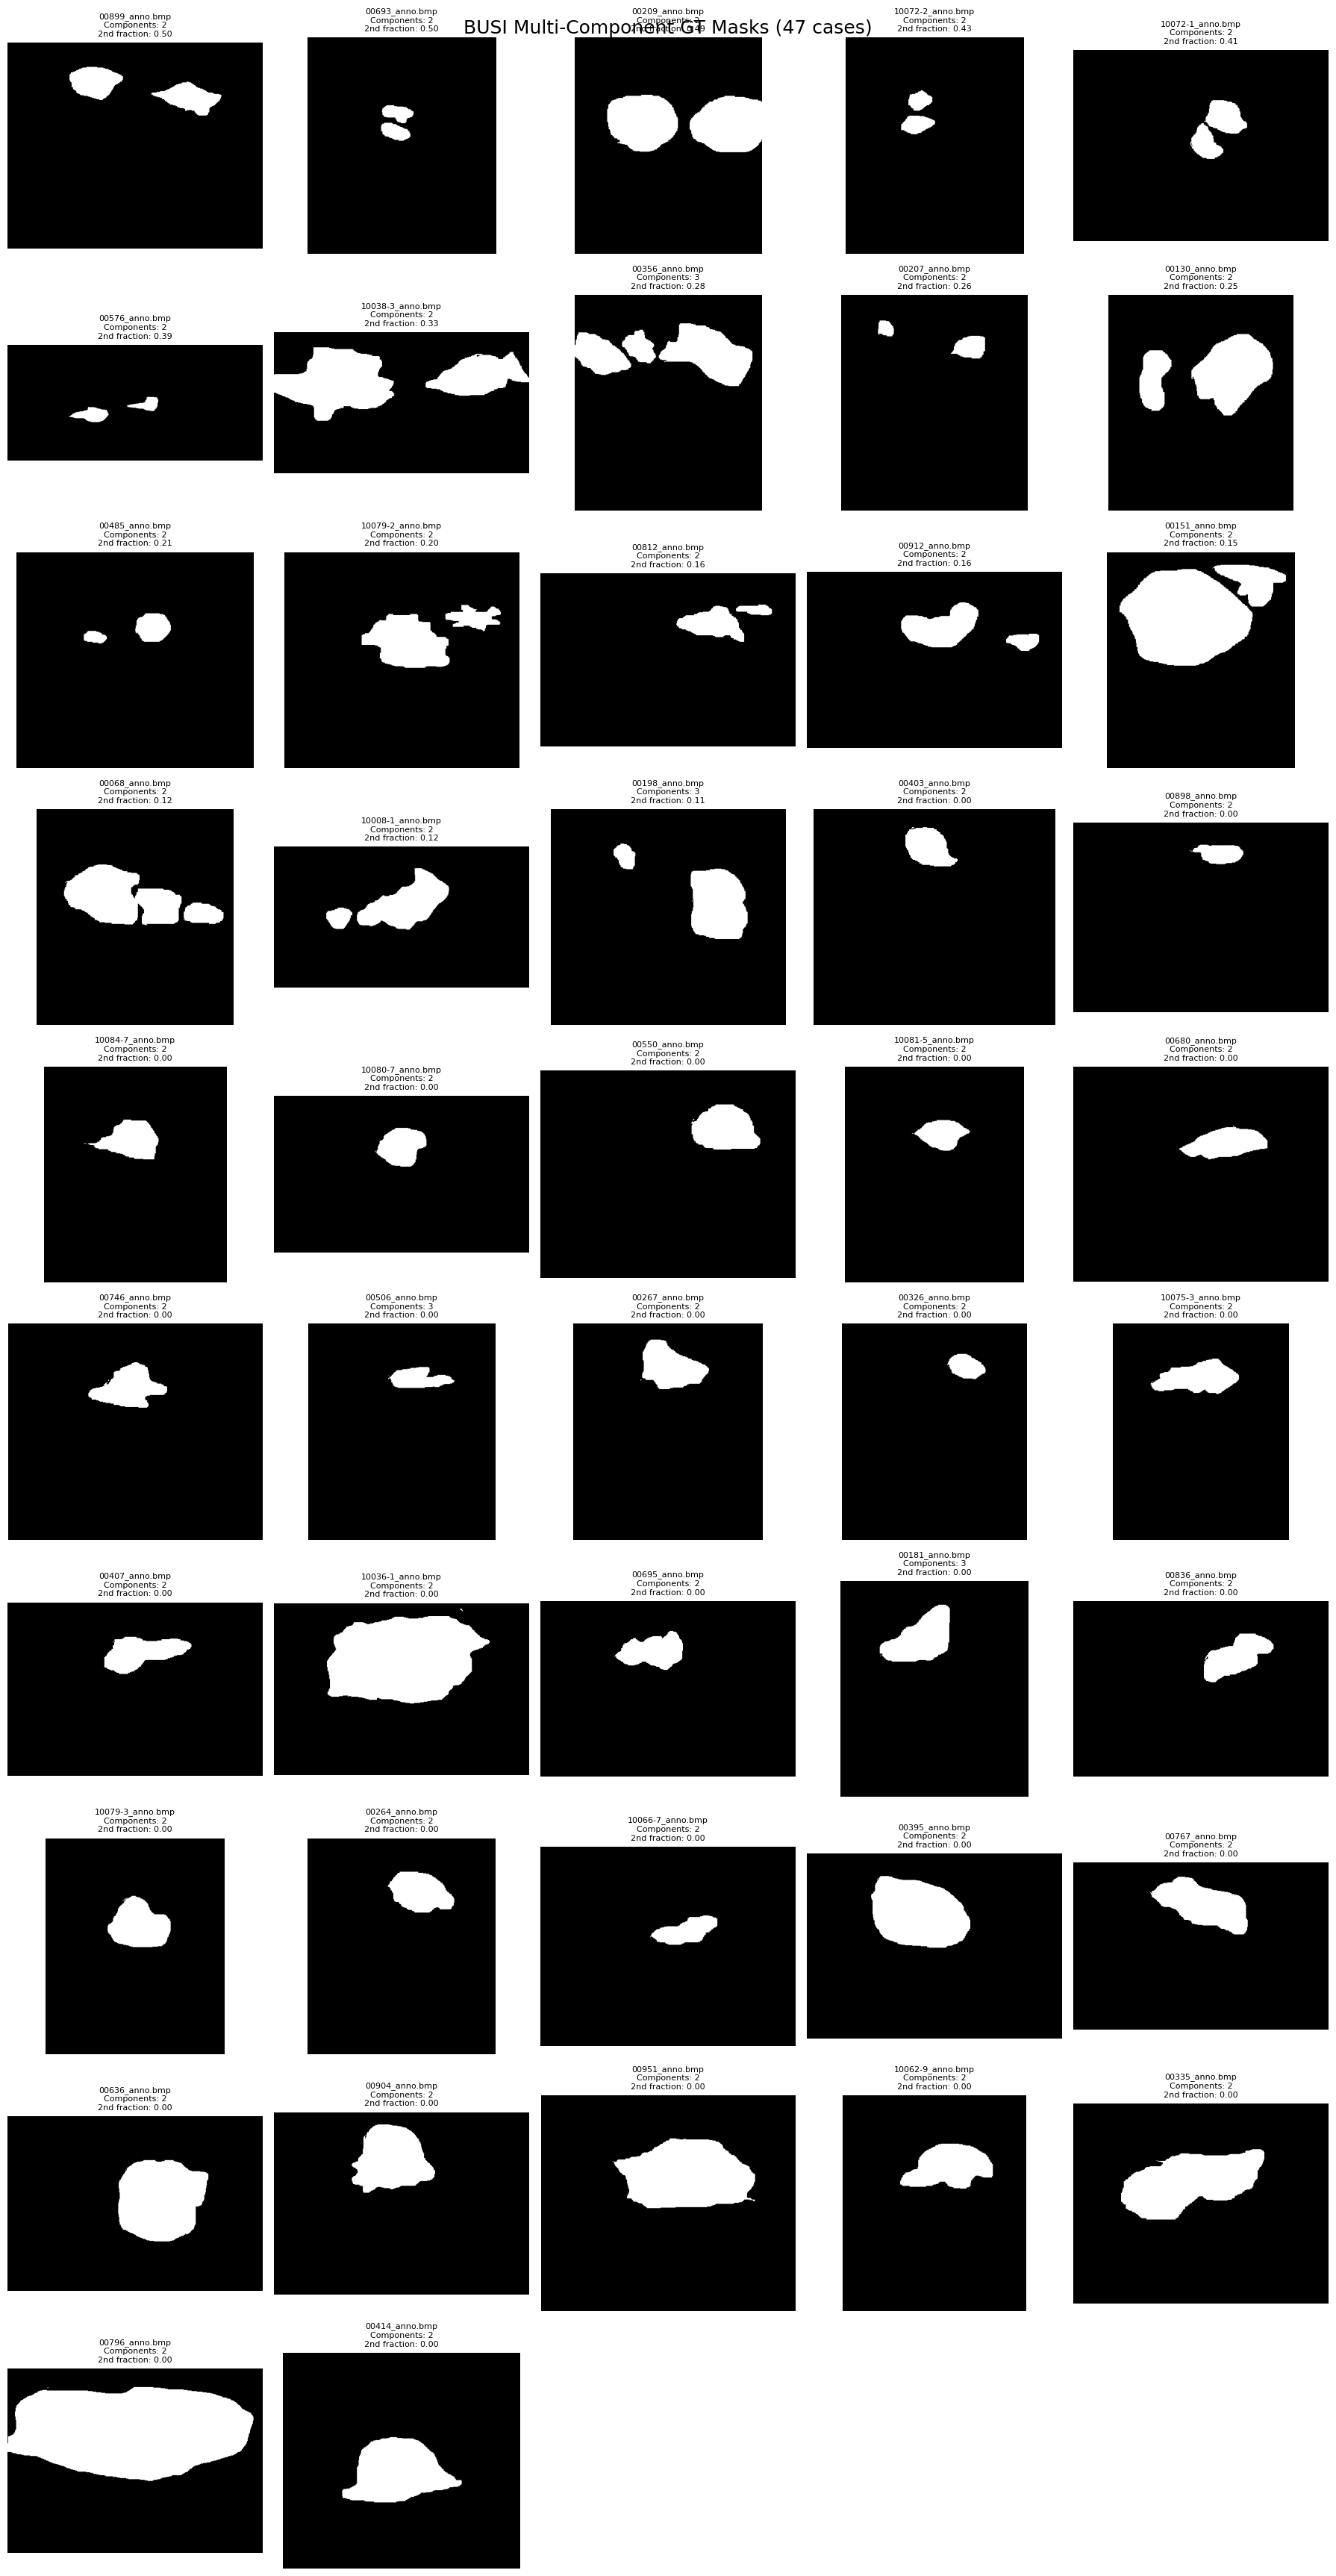

In [14]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# CONFIGURATION
# ============================================================

GT_FOLDER = r"E:\Research Datasets\Datasets\BUSI\masks"

# ============================================================
# FIND MULTI-COMPONENT MASKS
# ============================================================

files = sorted([
    f for f in os.listdir(GT_FOLDER)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"))
])

multi_component = []

for filename in files:

    path = os.path.join(GT_FOLDER, filename)

    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if mask is None:
        continue

    mask = (mask > 0).astype(np.uint8)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    lesion_components = num_labels - 1

    if lesion_components > 1:

        components = []

        for label in range(1, num_labels):

            area = stats[label, cv2.CC_STAT_AREA]

            components.append(area)

        components = sorted(components, reverse=True)

        multi_component.append({
            "image_name": filename,
            "components": lesion_components,
            "largest_area": components[0],
            "second_area": components[1],
            "total_area": sum(components),
            "second_fraction": components[1] / sum(components)
        })

multi_df = pd.DataFrame(multi_component)

# ============================================================
# SORT BY IMPORTANCE OF SECOND COMPONENT
# ============================================================

multi_df = multi_df.sort_values(
    "second_fraction",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("MULTI-COMPONENT MASK INSPECTION")
print("=" * 70)

print(f"Multi-component masks: {len(multi_df)}")

print("\nLargest secondary components:")
print(
    multi_df[
        [
            "image_name",
            "components",
            "largest_area",
            "second_area",
            "total_area",
            "second_fraction"
        ]
    ].head(20).to_string(index=False)
)

# ============================================================
# VISUALIZE
# ============================================================

N = len(multi_df)

cols = 5
rows = int(np.ceil(N / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(18, rows * 3.5)
)

axes = np.array(axes).flatten()

for i, row in multi_df.iterrows():

    filename = row["image_name"]

    path = os.path.join(GT_FOLDER, filename)

    mask = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    mask = (mask > 0).astype(np.uint8)

    axes[i].imshow(mask, cmap="gray")

    axes[i].set_title(
        f"{filename}\n"
        f"Components: {int(row['components'])}\n"
        f"2nd fraction: {row['second_fraction']:.2f}",
        fontsize=8
    )

    axes[i].axis("off")

# Turn off unused axes
for j in range(N, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "BUSI Multi-Component GT Masks (47 cases)",
    fontsize=18
)

plt.tight_layout()

plt.show()

In [15]:
import os
import re
import pandas as pd

# ============================================================
# CONFIGURATION
# ============================================================

GT_FOLDER = r"E:\Research Datasets\Datasets\BUSI\masks"

# ============================================================
# GET ALL MASK FILES
# ============================================================

files = sorted([
    f for f in os.listdir(GT_FOLDER)
    if f.lower().endswith((
        ".png", ".jpg", ".jpeg",
        ".bmp", ".tif", ".tiff"
    ))
])

print("=" * 70)
print("CHECKING FOR MULTIPLE MASK FILES PER IMAGE")
print("=" * 70)

print(f"Total mask files: {len(files)}")

# ============================================================
# EXTRACT BASE IMAGE IDENTIFIER
# ============================================================

records = []

for filename in files:

    # Remove extension
    name = os.path.splitext(filename)[0]

    # --------------------------------------------------------
    # Handle patterns such as:
    #
    # 00506_anno
    # 00506_anno1
    # 00506_anno2
    # 00506_anno_1
    # 00506_anno_2
    # --------------------------------------------------------

    match = re.match(
        r"^(.*?_anno)(?:_?(\d+))?$",
        name,
        re.IGNORECASE
    )

    if match:

        base = match.group(1)
        number = match.group(2)

        records.append({
            "filename": filename,
            "base_name": base,
            "mask_number": number
        })

    else:

        records.append({
            "filename": filename,
            "base_name": name,
            "mask_number": None
        })

df = pd.DataFrame(records)

# ============================================================
# FIND BASE NAMES WITH MULTIPLE MASK FILES
# ============================================================

counts = (
    df.groupby("base_name")
      .size()
      .reset_index(name="number_of_masks")
)

multiple = counts[counts["number_of_masks"] > 1]

print()
print("=" * 70)
print("RESULT")
print("=" * 70)

print(f"Unique image base names: {len(counts)}")
print(f"Base names with multiple mask files: {len(multiple)}")

# ============================================================
# SHOW RESULTS
# ============================================================

if len(multiple) > 0:

    print()
    print("Base names with multiple masks:")
    print()

    for _, row in multiple.iterrows():

        base = row["base_name"]

        matching_files = df[
            df["base_name"] == base
        ]["filename"].tolist()

        print(
            f"{base}  -->  "
            f"{len(matching_files)} masks"
        )

        for f in matching_files:
            print(f"    {f}")

else:

    print()
    print("No multiple mask files found.")

# ============================================================
# SAVE RESULTS
# ============================================================

output_path = os.path.join(
    GT_FOLDER,
    "multiple_mask_files_audit.csv"
)

multiple.to_csv(
    output_path,
    index=False
)

print()
print(f"Audit CSV saved to:")
print(output_path)

CHECKING FOR MULTIPLE MASK FILES PER IMAGE
Total mask files: 927

RESULT
Unique image base names: 927
Base names with multiple mask files: 0

No multiple mask files found.

Audit CSV saved to:
E:\Research Datasets\Datasets\BUSI\masks\multiple_mask_files_audit.csv



CASE: 00899_anno.bmp
Image: 00899.bmp
Mask : 00899_anno.bmp
Number of components: 2
Component 1: 2,709 pixels (50.10%)
Component 2: 2,698 pixels (49.90%)


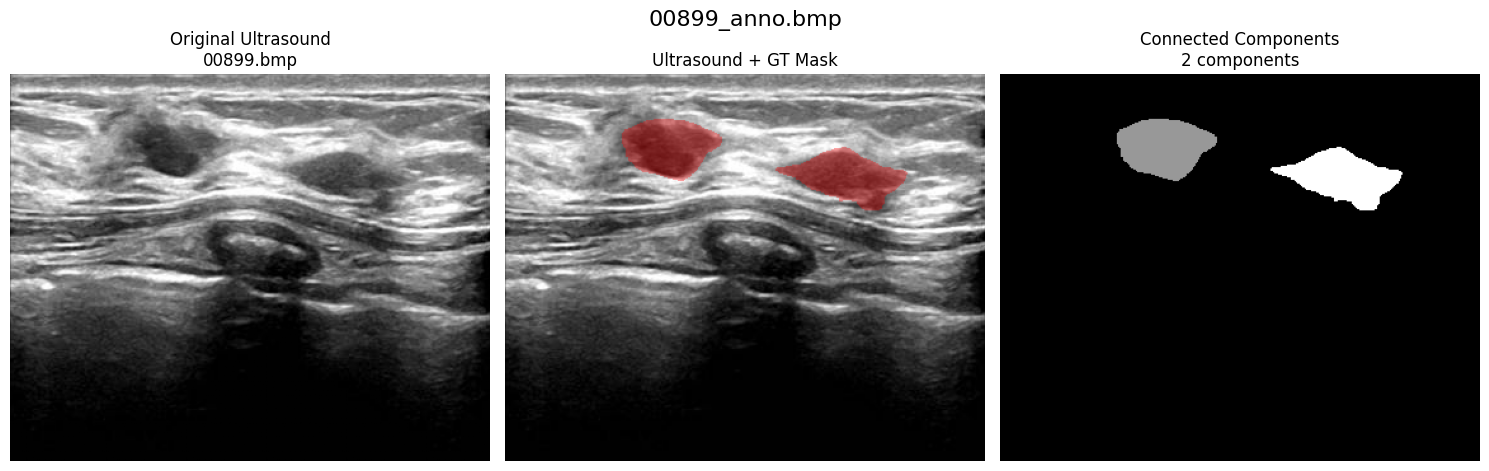


CASE: 00693_anno.bmp
Image: 00693.bmp
Mask : 00693_anno.bmp
Number of components: 2
Component 1: 1,952 pixels (50.45%)
Component 2: 1,917 pixels (49.55%)


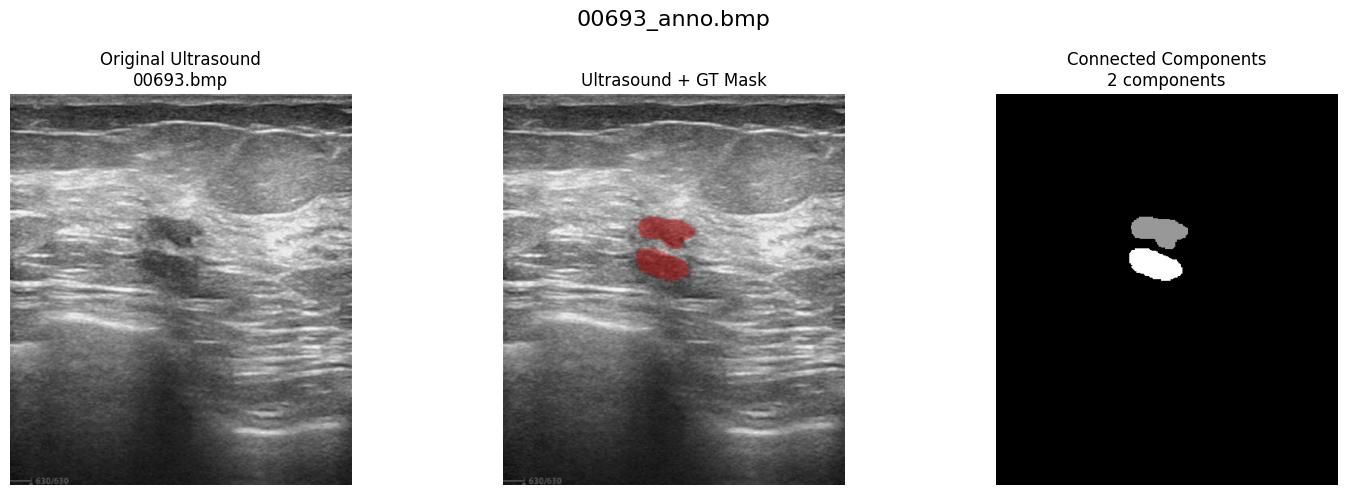


CASE: 00209_anno.bmp
Image: 00209.bmp
Mask : 00209_anno.bmp
Number of components: 2
Component 1: 11,832 pixels (51.12%)
Component 2: 11,315 pixels (48.88%)


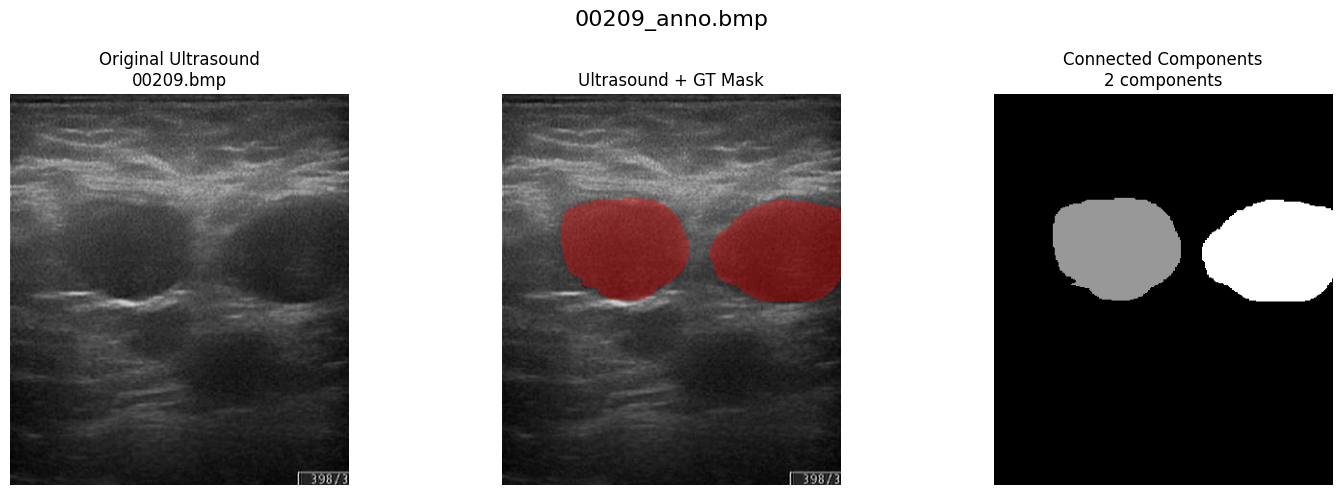


CASE: 10072-2_anno.bmp
Image: 10072-2.bmp
Mask : 10072-2_anno.bmp
Number of components: 2
Component 1: 2,193 pixels (57.15%)
Component 2: 1,644 pixels (42.85%)


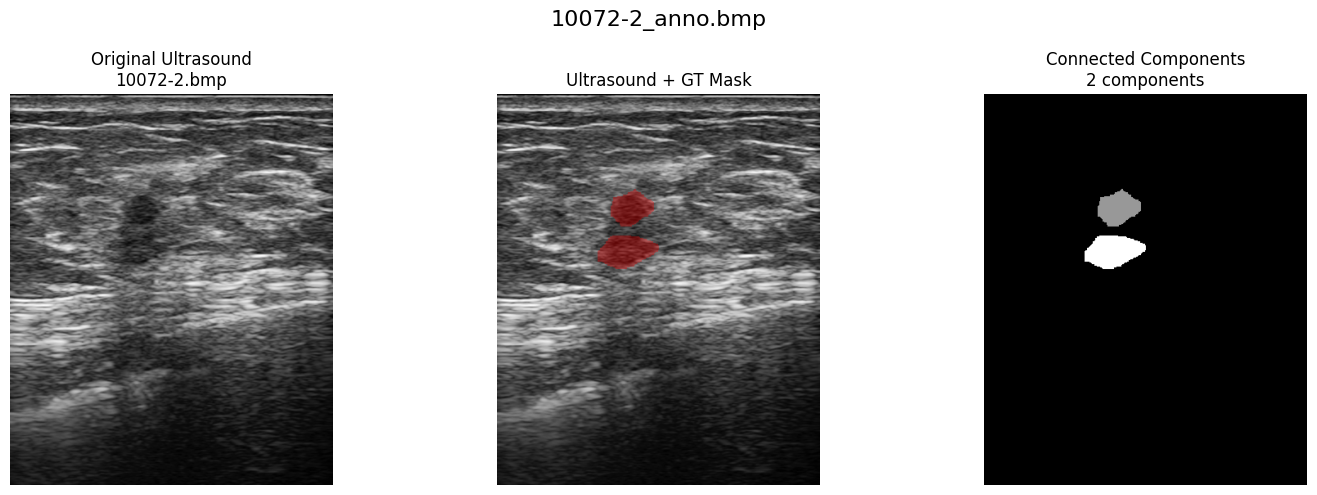


CASE: 10072-1_anno.bmp
Image: 10072-1.bmp
Mask : 10072-1_anno.bmp
Number of components: 2
Component 1: 4,384 pixels (59.03%)
Component 2: 3,043 pixels (40.97%)


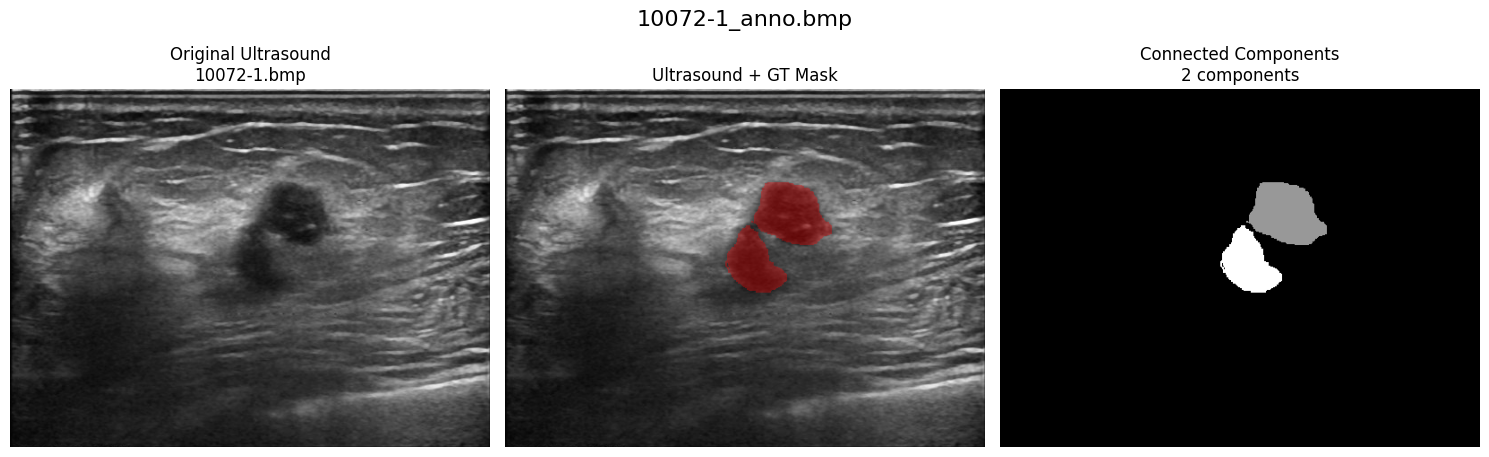


CASE: 00576_anno.bmp
Image: 00576.bmp
Mask : 00576_anno.bmp
Number of components: 2
Component 1: 4,065 pixels (60.61%)
Component 2: 2,642 pixels (39.39%)


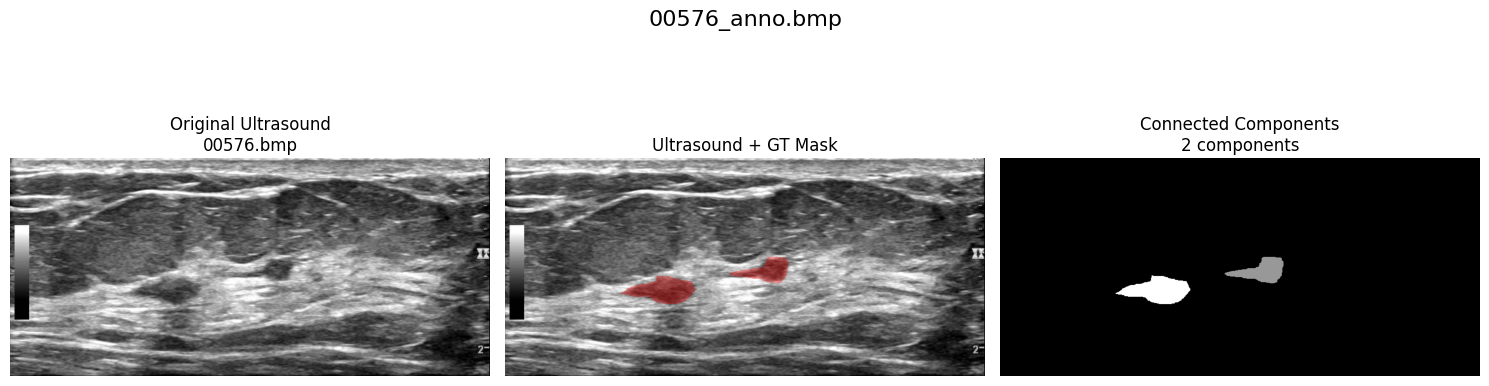


CASE: 00506_anno.bmp
Image: 00506.bmp
Mask : 00506_anno.bmp
Number of components: 3
Component 1: 4,896 pixels (99.94%)
Component 2: 2 pixels (0.04%)
Component 3: 1 pixels (0.02%)


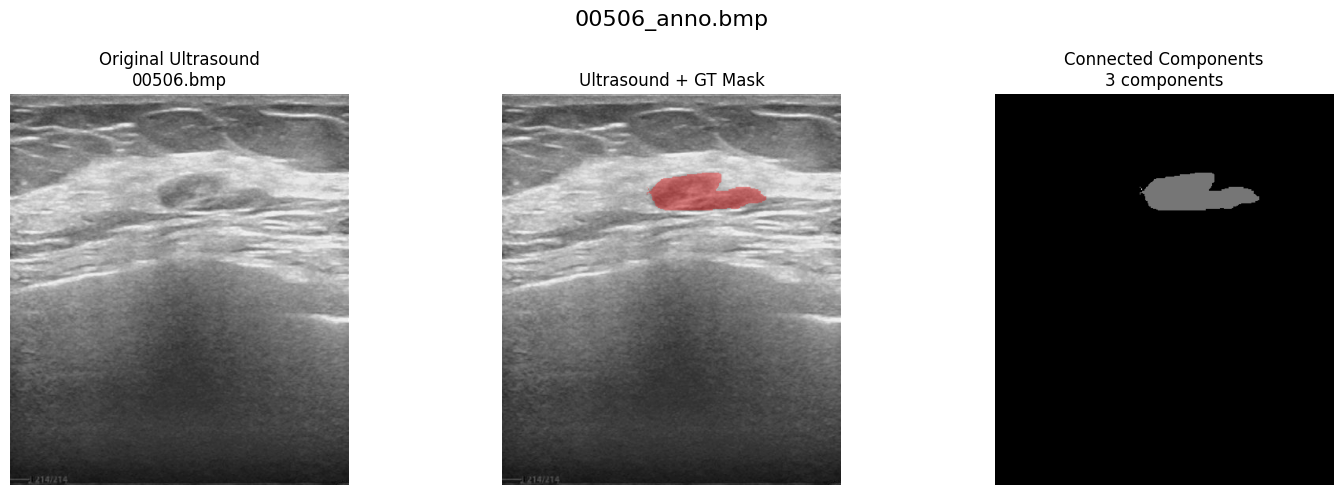


CASE: 10038-3_anno.bmp
Image: 10038-3.bmp
Mask : 10038-3_anno.bmp
Number of components: 2
Component 1: 16,129 pixels (66.53%)
Component 2: 8,116 pixels (33.47%)


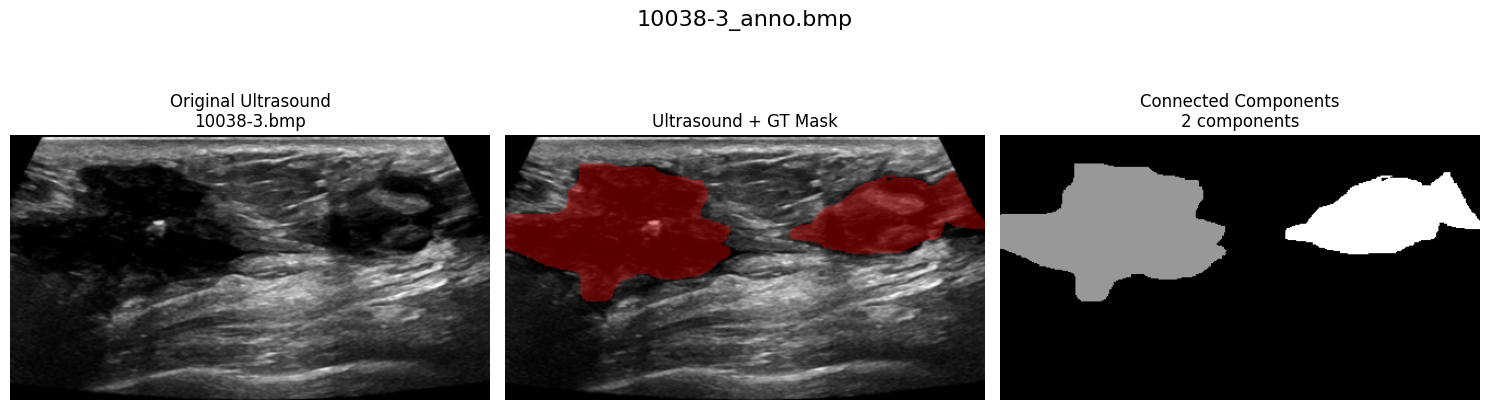


CASE: 00356_anno.bmp
Image: 00356.bmp
Mask : 00356_anno.bmp
Number of components: 3
Component 1: 11,793 pixels (59.32%)
Component 2: 5,585 pixels (28.09%)
Component 3: 2,503 pixels (12.59%)


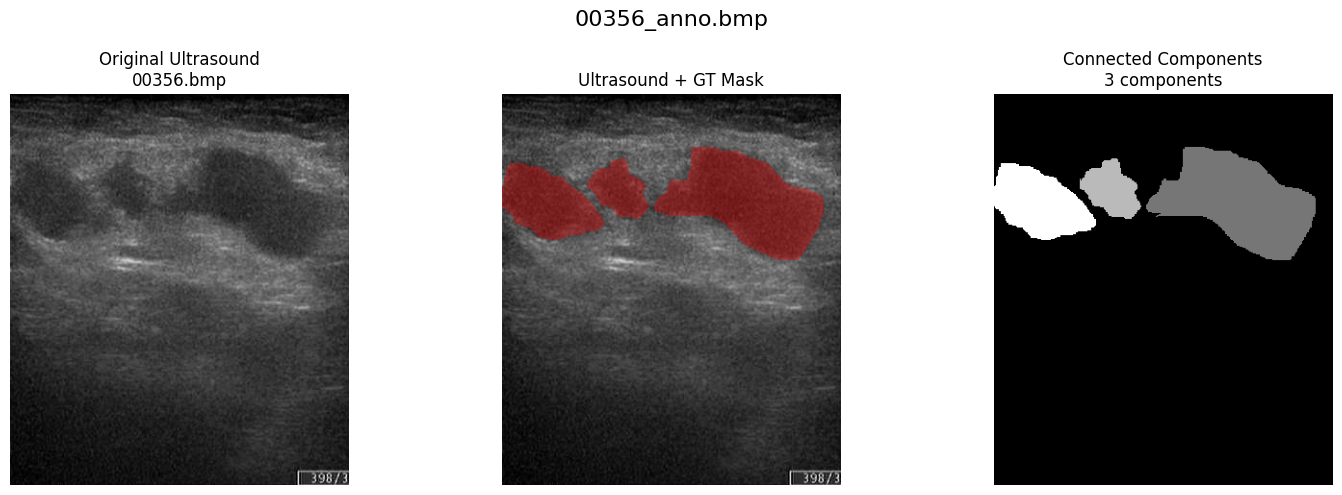

In [17]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURATION
# ============================================================

IMAGE_FOLDER = r"E:\Research Datasets\Datasets\BUSI\images"
MASK_FOLDER  = r"E:\Research Datasets\Datasets\BUSI\masks"

# Cases with substantial secondary components
TARGET_MASKS = [
    "00899_anno.bmp",
    "00693_anno.bmp",
    "00209_anno.bmp",
    "10072-2_anno.bmp",
    "10072-1_anno.bmp",
    "00576_anno.bmp", 
    "00506_anno.bmp",
    "10038-3_anno.bmp",
    "00356_anno.bmp"
]

# ============================================================
# FUNCTION TO FIND CORRESPONDING IMAGE
# ============================================================

def find_image(mask_filename):

    # Remove "_anno"
    base = mask_filename.replace("_anno", "")

    possible_extensions = [
        ".bmp",
        ".png",
        ".jpg",
        ".jpeg",
        ".tif",
        ".tiff"
    ]

    for ext in possible_extensions:

        candidate = os.path.join(
            IMAGE_FOLDER,
            os.path.splitext(base)[0] + ext
        )

        if os.path.exists(candidate):
            return candidate

    return None


# ============================================================
# PROCESS EACH MASK
# ============================================================

for mask_filename in TARGET_MASKS:

    print()
    print("=" * 70)
    print(f"CASE: {mask_filename}")
    print("=" * 70)

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    mask_path = os.path.join(
        MASK_FOLDER,
        mask_filename
    )

    image_path = find_image(mask_filename)

    if image_path is None:

        print("WARNING: Corresponding image not found.")
        continue

    print(f"Image: {os.path.basename(image_path)}")
    print(f"Mask : {mask_filename}")

    # --------------------------------------------------------
    # Read image
    # --------------------------------------------------------

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    if image is None or mask is None:

        print("ERROR: Could not read image or mask.")
        continue

    # --------------------------------------------------------
    # Binary mask
    # --------------------------------------------------------

    binary_mask = (
        mask > 0
    ).astype(np.uint8)

    # --------------------------------------------------------
    # Connected components
    # --------------------------------------------------------

    num_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=8
        )
    )

    num_components = num_labels - 1

    print(f"Number of components: {num_components}")

    # --------------------------------------------------------
    # Component information
    # --------------------------------------------------------

    component_areas = []

    for label in range(1, num_labels):

        area = stats[
            label,
            cv2.CC_STAT_AREA
        ]

        component_areas.append(area)

    total_area = sum(component_areas)

    for i, area in enumerate(
        sorted(component_areas, reverse=True),
        start=1
    ):

        fraction = area / total_area

        print(
            f"Component {i}: "
            f"{area:,} pixels "
            f"({fraction * 100:.2f}%)"
        )

    # --------------------------------------------------------
    # Create mask overlay
    # --------------------------------------------------------

    # Normalize image for display
    image_display = cv2.normalize(
        image,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    image_display = image_display.astype(
        np.uint8
    )

    # Create RGB image
    overlay = cv2.cvtColor(
        image_display,
        cv2.COLOR_GRAY2RGB
    )

    # Add red overlay where mask exists
    overlay[binary_mask > 0] = (
        255,
        0,
        0
    )

    # Blend with original
    blended = cv2.addWeighted(
        cv2.cvtColor(
            image_display,
            cv2.COLOR_GRAY2RGB
        ),
        0.65,
        overlay,
        0.35,
        0
    )

    # --------------------------------------------------------
    # Create component visualization
    # --------------------------------------------------------

    component_display = np.zeros(
        (*binary_mask.shape, 3),
        dtype=np.uint8
    )

    # Give each component a different display intensity
    for label in range(1, num_labels):

        intensity = int(
            50 + (
                205 *
                label /
                max(1, num_components)
            )
        )

        component_display[
            labels == label
        ] = (
            intensity,
            intensity,
            intensity
        )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    # Original
    axes[0].imshow(
        image_display,
        cmap="gray"
    )

    axes[0].set_title(
        f"Original Ultrasound\n"
        f"{os.path.basename(image_path)}"
    )

    axes[0].axis("off")

    # Overlay
    axes[1].imshow(
        blended
    )

    axes[1].set_title(
        "Ultrasound + GT Mask"
    )

    axes[1].axis("off")

    # Components
    axes[2].imshow(
        component_display,
        cmap="gray"
    )

    axes[2].set_title(
        f"Connected Components\n"
        f"{num_components} components"
    )

    axes[2].axis("off")

    plt.suptitle(
        mask_filename,
        fontsize=16
    )

    plt.tight_layout()

    plt.show()

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.measure import regionprops


# ============================================================
# CONFIGURATION
# ============================================================

GT_FOLDER = r"E:\Research Datasets\Datasets\BUSI\masks"

OUTPUT_CSV = r"E:\Research Datasets\Datasets\BUSI\gt_morphology_complete_v2.csv"


# ============================================================
# MORPHOLOGY CALCULATION
# ============================================================

def calculate_morphology(mask):

    # --------------------------------------------------------
    # Make binary mask
    #
    # IMPORTANT:
    # Keep ALL foreground pixels.
    # No connected component is discarded.
    # --------------------------------------------------------

    mask = (mask > 0).astype(np.uint8)

    image_area = mask.shape[0] * mask.shape[1]

    # --------------------------------------------------------
    # Check for empty mask
    # --------------------------------------------------------

    total_area = np.sum(mask)

    if total_area == 0:

        return {
            "area_pixels": np.nan,
            "normalized_area": np.nan,
            "aspect_ratio": np.nan,
            "eccentricity": np.nan,
            "circularity": np.nan,
            "solidity": np.nan,
            "boundary_regularity": np.nan
        }

    # --------------------------------------------------------
    # AREA
    #
    # Use ALL foreground pixels.
    # --------------------------------------------------------

    area = total_area

    normalized_area = area / image_area


    # --------------------------------------------------------
    # REGION PROPERTIES
    #
    # Use the complete mask.
    # --------------------------------------------------------

    props = regionprops(mask)

    if len(props) == 0:

        return {
            "area_pixels": np.nan,
            "normalized_area": np.nan,
            "aspect_ratio": np.nan,
            "eccentricity": np.nan,
            "circularity": np.nan,
            "solidity": np.nan,
            "boundary_regularity": np.nan
        }

    prop = props[0]


    # --------------------------------------------------------
    # ECCENTRICITY
    #
    # Same definition as original code.
    # --------------------------------------------------------

    eccentricity = prop.eccentricity


    # --------------------------------------------------------
    # ASPECT RATIO
    #
    # Same definition as original:
    #
    # Height / Width
    #
    # > 1 = taller than wide
    # < 1 = wider than tall
    # ~ 1 = approximately equal
    #
    # Bounding box covers ALL foreground pixels.
    # --------------------------------------------------------

    coords = np.column_stack(
        np.where(mask > 0)
    )

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    height = y_max - y_min + 1
    width = x_max - x_min + 1

    if width > 0:

        aspect_ratio = height / width

    else:

        aspect_ratio = np.nan


    # --------------------------------------------------------
    # FIND ALL EXTERNAL CONTOURS
    #
    # Do NOT select only the largest contour.
    # --------------------------------------------------------

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:

        return {
            "area_pixels": area,
            "normalized_area": normalized_area,
            "aspect_ratio": aspect_ratio,
            "eccentricity": eccentricity,
            "circularity": np.nan,
            "solidity": np.nan,
            "boundary_regularity": np.nan
        }


    # --------------------------------------------------------
    # TOTAL PERIMETER
    #
    # Sum perimeter of all external contours.
    # --------------------------------------------------------

    total_perimeter = 0.0

    for contour in contours:

        total_perimeter += cv2.arcLength(
            contour,
            True
        )


    # --------------------------------------------------------
    # CIRCULARITY
    #
    # 1 = highly circular
    # lower = more irregular
    #
    # Uses total annotated area and total boundary.
    # --------------------------------------------------------

    if total_perimeter > 0:

        circularity = (
            4 * np.pi * area
        ) / (
            total_perimeter ** 2
        )

    else:

        circularity = np.nan

    circularity = np.clip(
        circularity,
        0,
        1
    )


    # --------------------------------------------------------
    # SOLIDITY
    #
    # Area / Convex Hull Area
    #
    # IMPORTANT:
    # Convex hull is calculated from ALL foreground pixels.
    # --------------------------------------------------------

    points = np.column_stack(
        np.where(mask > 0)[::-1]
    ).astype(np.int32)

    if len(points) >= 3:

        hull = cv2.convexHull(points)

        hull_area = cv2.contourArea(
            hull
        )

        if hull_area > 0:

            solidity = area / hull_area

        else:

            solidity = np.nan

    else:

        solidity = np.nan

    solidity = np.clip(
        solidity,
        0,
        1
    )


    # --------------------------------------------------------
    # BOUNDARY REGULARITY
    #
    # Same conceptual definition as original:
    #
    #     1 / (1 + CV_radius)
    #
    # Higher = more regular
    # Lower = more irregular
    #
    # Uses ALL external contour points.
    # Centroid = centroid of complete GT mask.
    # --------------------------------------------------------

    centroid_x = prop.centroid[1]
    centroid_y = prop.centroid[0]

    radial_distances = []

    for contour in contours:

        contour_points = contour.reshape(-1, 2)

        x = contour_points[:, 0]
        y = contour_points[:, 1]

        distances = np.sqrt(
            (x - centroid_x) ** 2 +
            (y - centroid_y) ** 2
        )

        radial_distances.extend(
            distances.tolist()
        )


    if len(radial_distances) > 0:

        radial_distances = np.array(
            radial_distances
        )

        mean_radius = np.mean(
            radial_distances
        )

        std_radius = np.std(
            radial_distances
        )

        if mean_radius > 0:

            cv_radius = (
                std_radius /
                mean_radius
            )

            boundary_regularity = (
                1.0 /
                (1.0 + cv_radius)
            )

        else:

            boundary_regularity = np.nan

    else:

        boundary_regularity = np.nan


    boundary_regularity = np.clip(
        boundary_regularity,
        0,
        1
    )


    # --------------------------------------------------------
    # RETURN MORPHOLOGY
    # --------------------------------------------------------

    return {
        "area_pixels": area,
        "normalized_area": normalized_area,
        "aspect_ratio": aspect_ratio,
        "eccentricity": eccentricity,
        "circularity": circularity,
        "solidity": solidity,
        "boundary_regularity": boundary_regularity
    }


# ============================================================
# PROCESS ALL MASKS
# ============================================================

results = []

files = sorted([
    f for f in os.listdir(GT_FOLDER)
    if f.lower().endswith(
        (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
    )
])


print("=" * 60)
print("BUILDING COMPLETE-GT MORPHOLOGY DATASET")
print("=" * 60)

print(f"GT folder: {GT_FOLDER}")
print(f"Masks found: {len(files)}")
print()


for i, filename in enumerate(files):

    mask_path = os.path.join(
        GT_FOLDER,
        filename
    )

    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:

        print(
            f"WARNING: Could not read {filename}"
        )

        continue


    morphology = calculate_morphology(
        mask
    )

    morphology["image_name"] = filename

    results.append(
        morphology
    )


    if (i + 1) % 50 == 0:

        print(
            f"Processed {i + 1}/{len(files)}"
        )


# ============================================================
# CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(
    results
)


# Put image name first

columns = [
    "image_name",
    "area_pixels",
    "normalized_area",
    "aspect_ratio",
    "eccentricity",
    "circularity",
    "solidity",
    "boundary_regularity"
]

df = df[columns]


# ============================================================
# SAVE CSV
# ============================================================

df.to_csv(
    OUTPUT_CSV,
    index=False
)


# ============================================================
# OUTPUT
# ============================================================

print()

print("=" * 60)
print("DONE")
print("=" * 60)

print(
    f"Images processed: {len(df)}"
)

print(
    f"CSV saved to: {OUTPUT_CSV}"
)

print()

print("First 10 rows:")

print(
    df.head(10)
)

print()

print("Missing values:")

print(
    df.isna().sum()
)

print()

print("Summary statistics:")

print(
    df.describe()
)


# ============================================================
# VALIDATION CHECKS
# ============================================================

print()

print("=" * 60)
print("VALIDATION CHECKS")
print("=" * 60)


# Solidity

solidity_out_of_range = df[
    (df["solidity"] < 0) |
    (df["solidity"] > 1)
].shape[0]

print(
    f"Solidity outside [0,1]: "
    f"{solidity_out_of_range}"
)


# Circularity

circularity_out_of_range = df[
    (df["circularity"] < 0) |
    (df["circularity"] > 1)
].shape[0]

print(
    f"Circularity outside [0,1]: "
    f"{circularity_out_of_range}"
)


# Boundary regularity

br_out_of_range = df[
    (df["boundary_regularity"] < 0) |
    (df["boundary_regularity"] > 1)
].shape[0]

print(
    f"Boundary regularity outside [0,1]: "
    f"{br_out_of_range}"
)


# Aspect ratio

aspect_ratio_invalid = df[
    df["aspect_ratio"] <= 0
].shape[0]

print(
    f"Invalid aspect ratio (<=0): "
    f"{aspect_ratio_invalid}"
)


print()

print("Metric ranges:")

print(
    f"  Normalized area:     "
    f"[{df['normalized_area'].min():.3f}, "
    f"{df['normalized_area'].max():.3f}]"
)

print(
    f"  Aspect ratio:        "
    f"[{df['aspect_ratio'].min():.3f}, "
    f"{df['aspect_ratio'].max():.3f}]"
)

print(
    f"  Eccentricity:        "
    f"[{df['eccentricity'].min():.3f}, "
    f"{df['eccentricity'].max():.3f}]"
)

print(
    f"  Circularity:         "
    f"[{df['circularity'].min():.3f}, "
    f"{df['circularity'].max():.3f}]"
)

print(
    f"  Solidity:            "
    f"[{df['solidity'].min():.3f}, "
    f"{df['solidity'].max():.3f}]"
)

print(
    f"  Boundary regularity: "
    f"[{df['boundary_regularity'].min():.3f}, "
    f"{df['boundary_regularity'].max():.3f}]"
)

print()

print("Morphology dataset successfully created.")

BUILDING COMPLETE-GT MORPHOLOGY DATASET
GT folder: E:\Research Datasets\Datasets\BUSI\masks
Masks found: 927

Processed 50/927
Processed 100/927
Processed 150/927
Processed 200/927
Processed 250/927
Processed 300/927
Processed 350/927
Processed 400/927
Processed 450/927
Processed 500/927
Processed 550/927
Processed 600/927
Processed 650/927
Processed 700/927
Processed 750/927
Processed 800/927
Processed 850/927
Processed 900/927

DONE
Images processed: 927
CSV saved to: E:\Research Datasets\Datasets\BUSI\gt_morphology_complete_v2.csv

First 10 rows:
       image_name  area_pixels  normalized_area  aspect_ratio  eccentricity  \
0  00001_anno.bmp        67278         0.373987      0.817337      0.641230   
1  00002_anno.bmp         2056         0.011429      1.173913      0.623299   
2  00003_anno.bmp        12020         0.079314      0.621118      0.809274   
3  00006_anno.bmp        13894         0.050387      0.423077      0.897346   
4  00007_anno.bmp         9772         0.055424  

BUSI GT MORPHOLOGY — DISTRIBUTION & CORRELATION ANALYSIS
CSV: E:\Research Datasets\Datasets\BUSI\gt_morphology_complete.csv
Total images: 927

Morphology features:
  - normalized_area
  - aspect_ratio
  - eccentricity
  - circularity
  - solidity
  - boundary_regularity

DATA VALIDATION

Missing values:
normalized_area        0
aspect_ratio           0
eccentricity           0
circularity            0
solidity               0
boundary_regularity    0
dtype: int64

Number of unique values:
normalized_area        927
aspect_ratio           834
eccentricity           927
circularity            927
solidity               886
boundary_regularity    927
dtype: int64

DISTRIBUTION SUMMARY
            feature  count   mean  median    std    min     q1     q3    max  skewness    iqr  lower_outlier_bound  upper_outlier_bound  outlier_count  outlier_percent
    normalized_area    927 0.0666  0.0432 0.0670 0.0054 0.0223 0.0801 0.3768    1.9965 0.0577              -0.0643               0.1667      

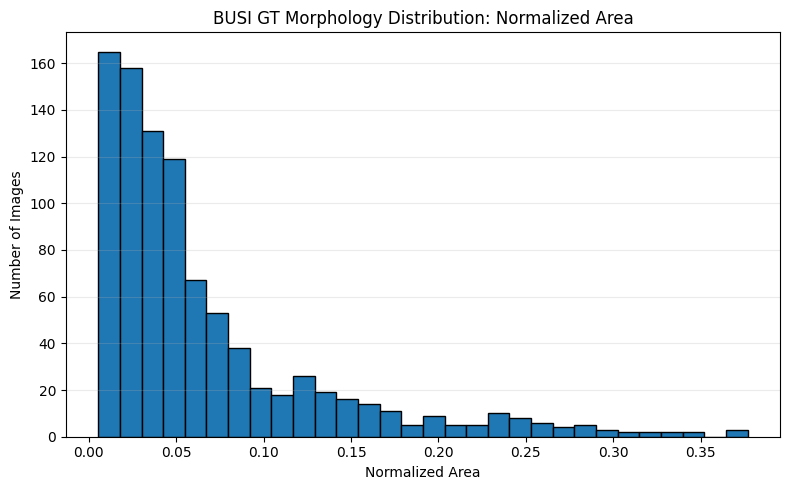

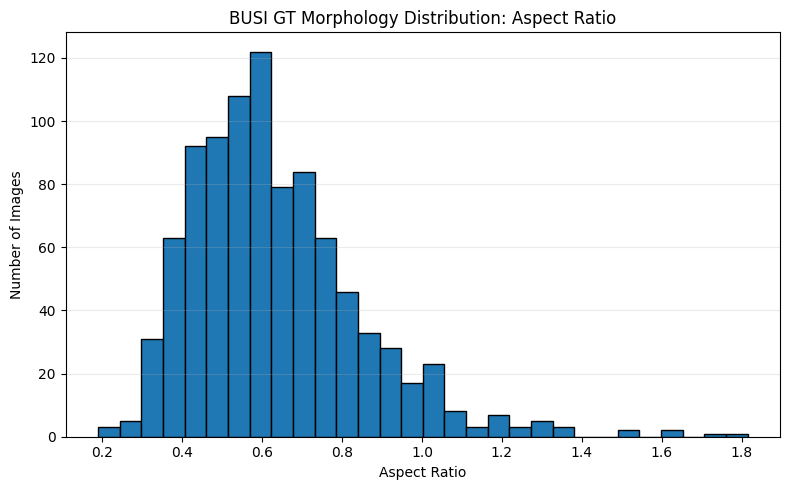

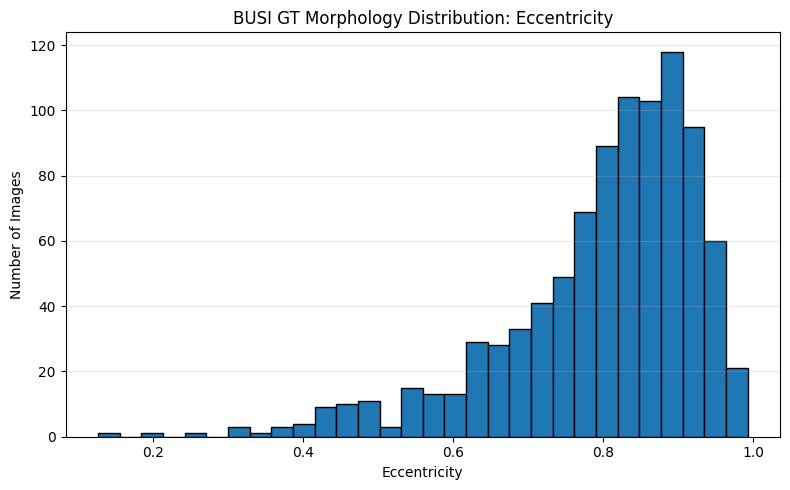

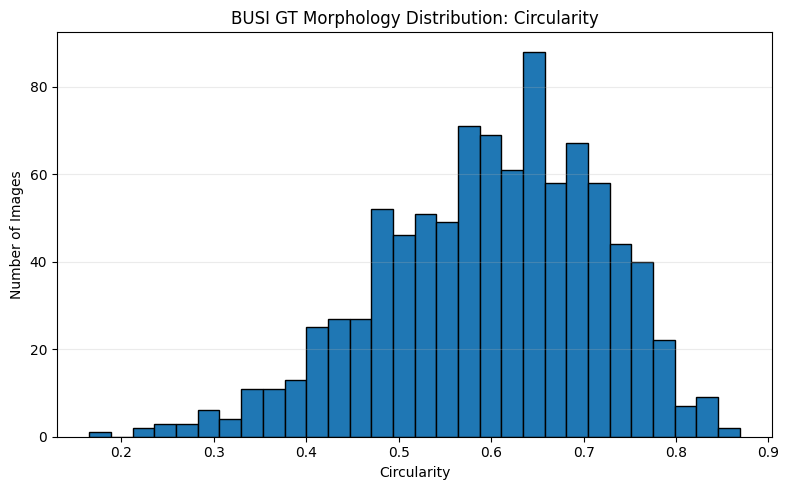

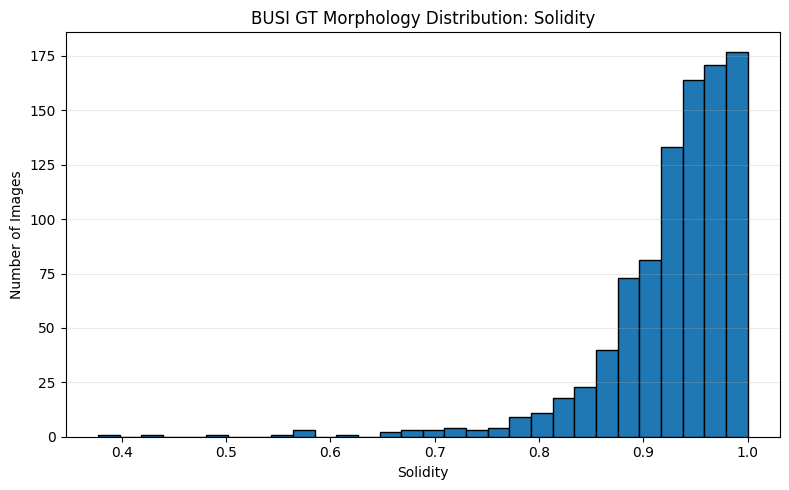

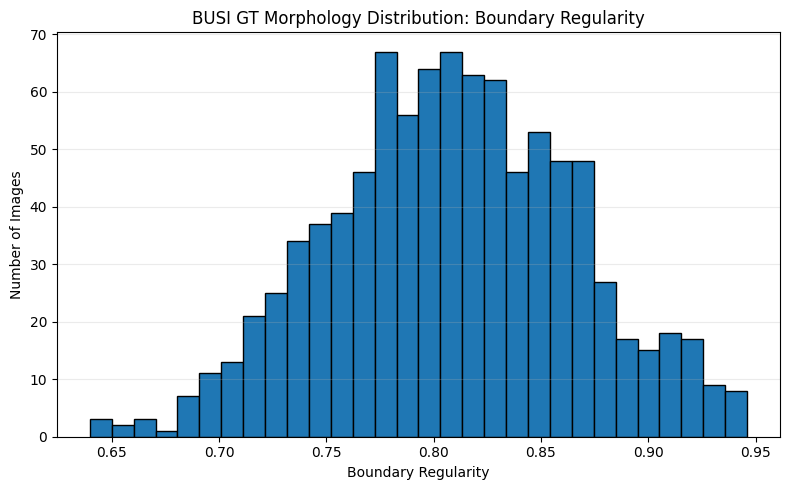

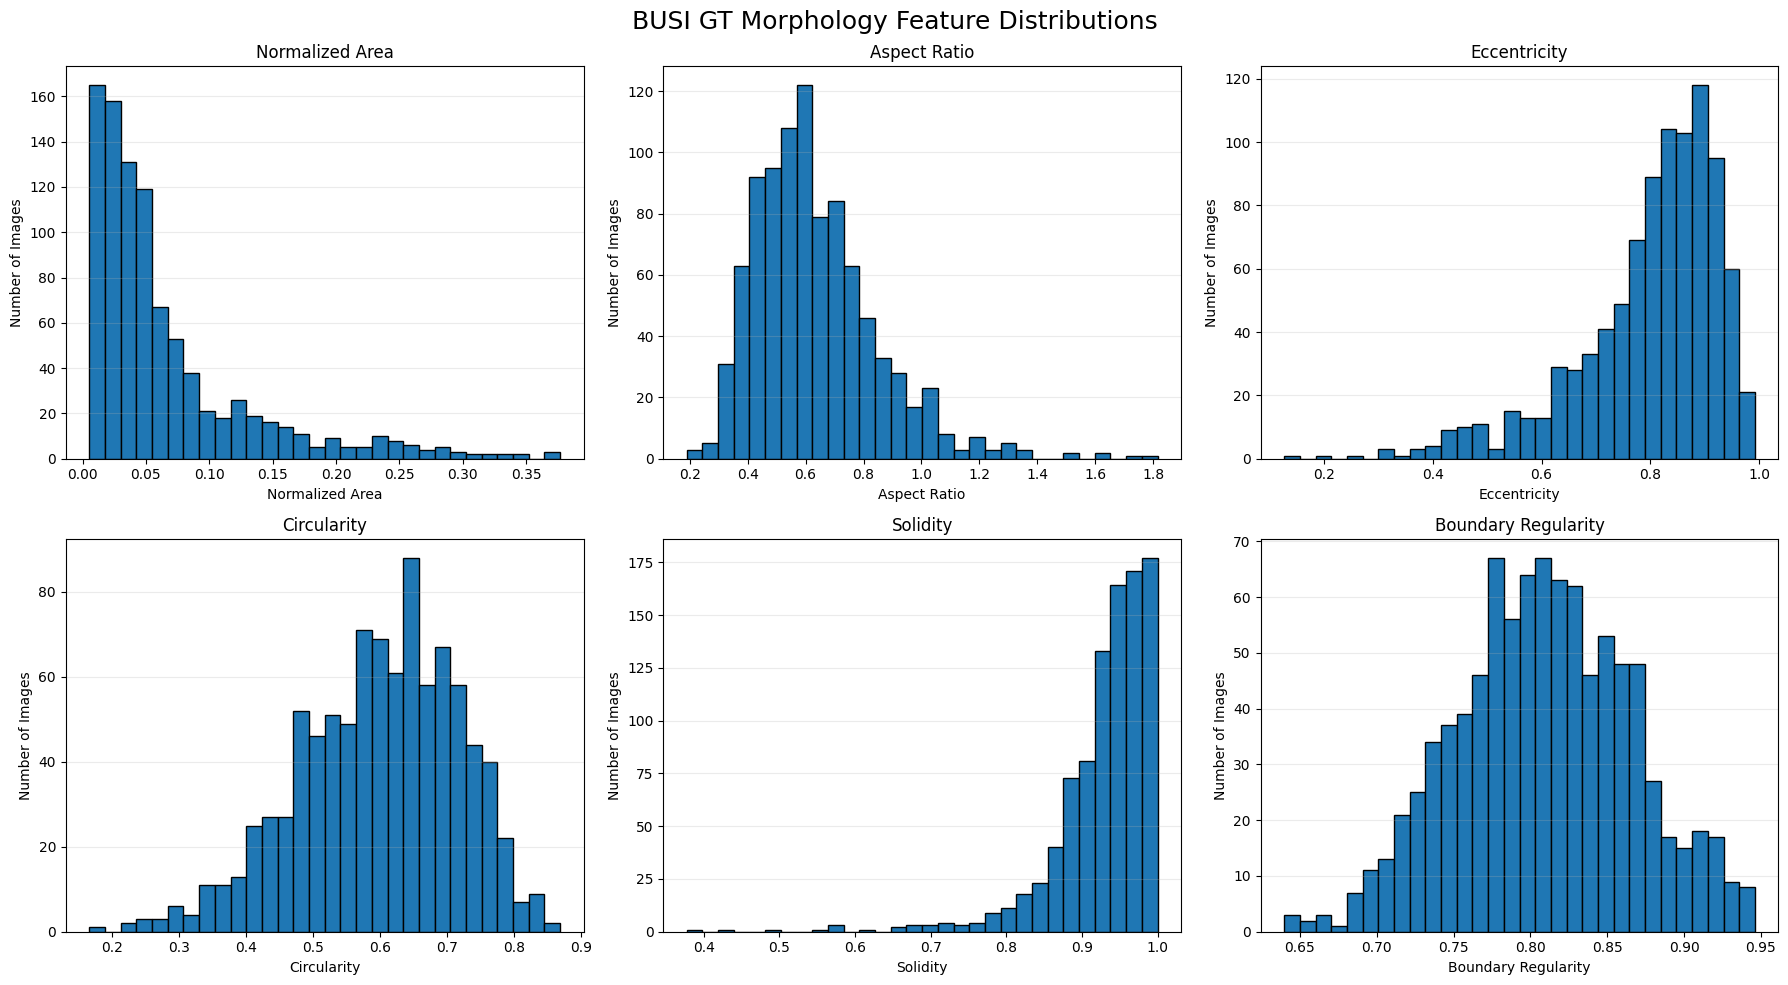


PEARSON CORRELATION MATRIX
                     normalized_area  aspect_ratio  eccentricity  circularity  solidity  boundary_regularity
normalized_area                1.000        -0.063         0.009       -0.145    -0.121                0.007
aspect_ratio                  -0.063         1.000        -0.717        0.457     0.138                0.697
eccentricity                   0.009        -0.717         1.000       -0.499    -0.182               -0.856
circularity                   -0.145         0.457        -0.499        1.000     0.786                0.764
solidity                      -0.121         0.138        -0.182        0.786     1.000                0.485
boundary_regularity            0.007         0.697        -0.856        0.764     0.485                1.000

SPEARMAN CORRELATION MATRIX
                     normalized_area  aspect_ratio  eccentricity  circularity  solidity  boundary_regularity
normalized_area                1.000        -0.066         0.048       

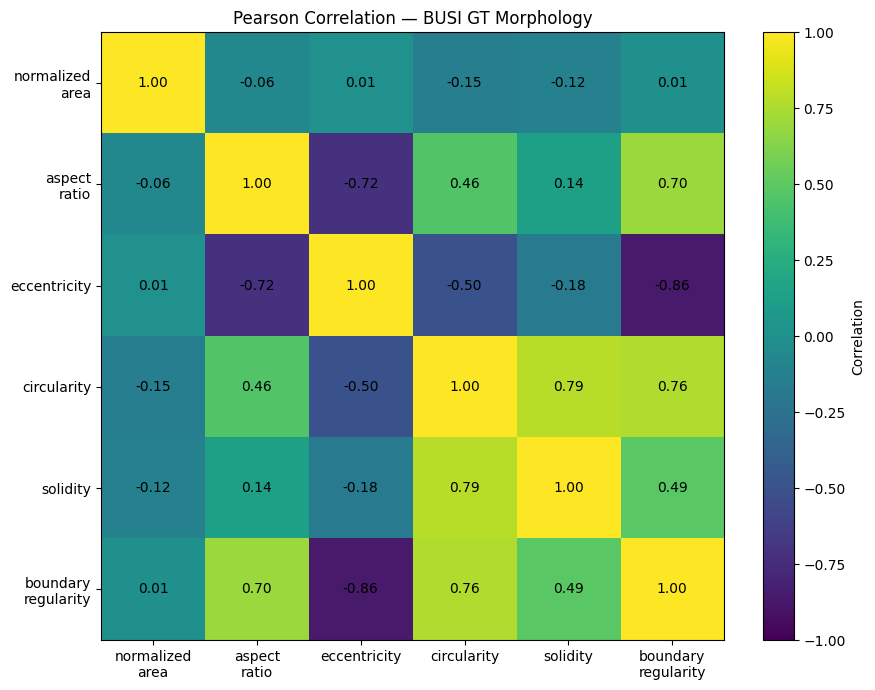

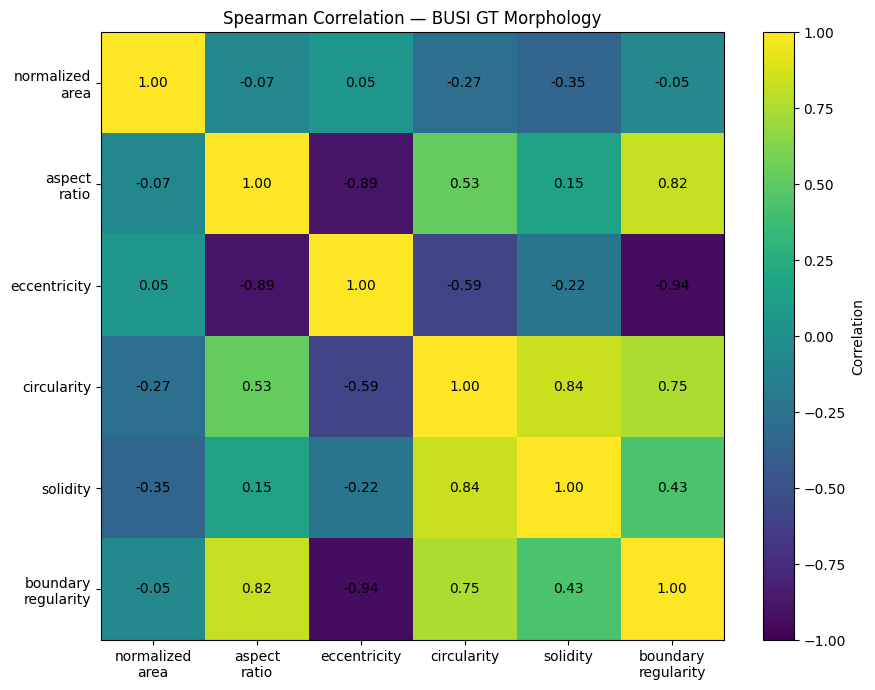


PAIRWISE CORRELATION TESTS
      feature_1           feature_2  pearson_r  pearson_p  spearman_r  spearman_p
normalized_area        aspect_ratio    -0.0631     0.0547     -0.0662      0.0439
normalized_area        eccentricity     0.0087     0.7902      0.0480      0.1441
normalized_area         circularity    -0.1453     0.0000     -0.2707      0.0000
normalized_area            solidity    -0.1206     0.0002     -0.3506      0.0000
normalized_area boundary_regularity     0.0074     0.8224     -0.0547      0.0959
   aspect_ratio        eccentricity    -0.7174     0.0000     -0.8903      0.0000
   aspect_ratio         circularity     0.4573     0.0000      0.5292      0.0000
   aspect_ratio            solidity     0.1378     0.0000      0.1533      0.0000
   aspect_ratio boundary_regularity     0.6974     0.0000      0.8209      0.0000
   eccentricity         circularity    -0.4993     0.0000     -0.5855      0.0000
   eccentricity            solidity    -0.1825     0.0000     -0.2202 

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, pearsonr, spearmanr


# ============================================================
# CONFIGURATION
# ============================================================

CSV_PATH = r"E:\Research Datasets\Datasets\BUSI\gt_morphology_complete.csv"

OUTPUT_FOLDER = r"E:\Research Datasets\Datasets\BUSI\gt_morphology_analysis"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(CSV_PATH)

FEATURES = [
    "normalized_area",
    "aspect_ratio",
    "eccentricity",
    "circularity",
    "solidity",
    "boundary_regularity"
]

print("=" * 70)
print("BUSI GT MORPHOLOGY — DISTRIBUTION & CORRELATION ANALYSIS")
print("=" * 70)

print(f"CSV: {CSV_PATH}")
print(f"Total images: {len(df)}")
print()

print("Morphology features:")
for feature in FEATURES:
    print(f"  - {feature}")


# ============================================================
# BASIC VALIDATION
# ============================================================

print()
print("=" * 70)
print("DATA VALIDATION")
print("=" * 70)

print("\nMissing values:")
print(df[FEATURES].isna().sum())

print("\nNumber of unique values:")
print(df[FEATURES].nunique())


# ============================================================
# DISTRIBUTION SUMMARY
# ============================================================

summary_rows = []

for feature in FEATURES:

    x = df[feature].dropna()

    # IQR outliers
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = x[
        (x < lower_bound) |
        (x > upper_bound)
    ]

    summary_rows.append({
        "feature": feature,
        "count": len(x),
        "mean": x.mean(),
        "median": x.median(),
        "std": x.std(),
        "min": x.min(),
        "q1": Q1,
        "q3": Q3,
        "max": x.max(),
        "skewness": skew(x),
        "iqr": IQR,
        "lower_outlier_bound": lower_bound,
        "upper_outlier_bound": upper_bound,
        "outlier_count": len(outliers),
        "outlier_percent": 100 * len(outliers) / len(x)
    })


distribution_summary = pd.DataFrame(summary_rows)

summary_path = os.path.join(
    OUTPUT_FOLDER,
    "morphology_distribution_summary.csv"
)

distribution_summary.to_csv(
    summary_path,
    index=False
)


print()
print("=" * 70)
print("DISTRIBUTION SUMMARY")
print("=" * 70)

print(
    distribution_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# HISTOGRAMS
# ============================================================

print()
print("=" * 70)
print("CREATING HISTOGRAMS")
print("=" * 70)


for feature in FEATURES:

    x = df[feature].dropna()

    plt.figure(figsize=(8, 5))

    plt.hist(
        x,
        bins=30,
        edgecolor="black"
    )

    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("Number of Images")

    plt.title(
        f"BUSI GT Morphology Distribution: "
        f"{feature.replace('_', ' ').title()}"
    )

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()

    output_path = os.path.join(
        OUTPUT_FOLDER,
        f"histogram_{feature}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ============================================================
# COMBINED HISTOGRAM FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for i, feature in enumerate(FEATURES):

    x = df[feature].dropna()

    axes[i].hist(
        x,
        bins=30,
        edgecolor="black"
    )

    axes[i].set_title(
        feature.replace("_", " ").title()
    )

    axes[i].set_xlabel(
        feature.replace("_", " ").title()
    )

    axes[i].set_ylabel(
        "Number of Images"
    )

    axes[i].grid(
        axis="y",
        alpha=0.25
    )


fig.suptitle(
    "BUSI GT Morphology Feature Distributions",
    fontsize=18
)

plt.tight_layout()

combined_histogram_path = os.path.join(
    OUTPUT_FOLDER,
    "all_morphology_histograms.png"
)

plt.savefig(
    combined_histogram_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# PEARSON CORRELATION
# ============================================================

pearson_corr = df[FEATURES].corr(
    method="pearson"
)

pearson_path = os.path.join(
    OUTPUT_FOLDER,
    "pearson_correlation.csv"
)

pearson_corr.to_csv(
    pearson_path
)


# ============================================================
# SPEARMAN CORRELATION
# ============================================================

spearman_corr = df[FEATURES].corr(
    method="spearman"
)

spearman_path = os.path.join(
    OUTPUT_FOLDER,
    "spearman_correlation.csv"
)

spearman_corr.to_csv(
    spearman_path
)


# ============================================================
# PRINT CORRELATION MATRICES
# ============================================================

print()
print("=" * 70)
print("PEARSON CORRELATION MATRIX")
print("=" * 70)

print(
    pearson_corr.round(3).to_string()
)


print()
print("=" * 70)
print("SPEARMAN CORRELATION MATRIX")
print("=" * 70)

print(
    spearman_corr.round(3).to_string()
)


# ============================================================
# CORRELATION HEATMAP FUNCTION
# ============================================================

def plot_correlation_heatmap(
    correlation_matrix,
    title,
    output_path
):

    plt.figure(
        figsize=(9, 7)
    )

    plt.imshow(
        correlation_matrix,
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    plt.colorbar(
        label="Correlation"
    )

    plt.xticks(
        range(len(FEATURES)),
        [
            f.replace("_", "\n")
            for f in FEATURES
        ],
        rotation=0
    )

    plt.yticks(
        range(len(FEATURES)),
        [
            f.replace("_", "\n")
            for f in FEATURES
        ]
    )

    # Add values
    for i in range(len(FEATURES)):

        for j in range(len(FEATURES)):

            value = correlation_matrix.iloc[i, j]

            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center"
            )

    plt.title(title)

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ============================================================
# PEARSON HEATMAP
# ============================================================

plot_correlation_heatmap(
    pearson_corr,
    "Pearson Correlation — BUSI GT Morphology",
    os.path.join(
        OUTPUT_FOLDER,
        "pearson_correlation_heatmap.png"
    )
)


# ============================================================
# SPEARMAN HEATMAP
# ============================================================

plot_correlation_heatmap(
    spearman_corr,
    "Spearman Correlation — BUSI GT Morphology",
    os.path.join(
        OUTPUT_FOLDER,
        "spearman_correlation_heatmap.png"
    )
)


# ============================================================
# PAIRWISE CORRELATION SIGNIFICANCE
# ============================================================

correlation_tests = []

for i in range(len(FEATURES)):

    for j in range(i + 1, len(FEATURES)):

        feature_x = FEATURES[i]
        feature_y = FEATURES[j]

        x = df[feature_x]
        y = df[feature_y]

        valid = (
            x.notna() &
            y.notna()
        )

        x_valid = x[valid]
        y_valid = y[valid]

        pearson_r, pearson_p = pearsonr(
            x_valid,
            y_valid
        )

        spearman_r, spearman_p = spearmanr(
            x_valid,
            y_valid
        )

        correlation_tests.append({

            "feature_1": feature_x,

            "feature_2": feature_y,

            "pearson_r": pearson_r,

            "pearson_p": pearson_p,

            "spearman_r": spearman_r,

            "spearman_p": spearman_p
        })


correlation_tests_df = pd.DataFrame(
    correlation_tests
)

correlation_tests_path = os.path.join(
    OUTPUT_FOLDER,
    "pairwise_correlation_tests.csv"
)

correlation_tests_df.to_csv(
    correlation_tests_path,
    index=False
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print()
print("=" * 70)
print("PAIRWISE CORRELATION TESTS")
print("=" * 70)

print(
    correlation_tests_df.round(4).to_string(
        index=False
    )
)


print()
print("=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

print(f"\nOutput folder:")
print(OUTPUT_FOLDER)

print("\nGenerated files:")

for filename in sorted(
    os.listdir(OUTPUT_FOLDER)
):

    print(
        f"  - {filename}"
    )